# Titanic — Exploratory Data Analysis & Feature Engineering

**Author:** baidarbe01EDU_Astana_03_2026  
**Goal:** Predict survival on the Titanic using machine learning.

## What changed vs first attempt
Our first feature set gave poor Kaggle scores across all 5 models — best was **0.799** (Decision Tree and KNN), worst was **0.777** (Logistic Regression).  
The problem: label-encoding Title and Embarked imposed a false numerical ordering the models treated as real signal.  
This notebook switches to **one-hot encoding** for Title and Embarked, and moves reusable logic into modular preprocessing scripts.

## Learning Objectives
- Feature engineering: why encoding choice matters (label vs one-hot)
- EDA for classification problems
- Handling missing data
- Cross-validation to prevent overfitting
- Comparing 5 ML models and submitting each to Kaggle separately
- Evaluation metrics: accuracy, precision, recall, F1

---
## 1. Imports

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Add scripts/ to path so we can import preprocessing.py
sys.path.append(os.path.abspath('../scripts'))
from preprocessing import extract_group_survival, clean_data
print('Custom scripts imported successfully!')

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Cross-validation & tuning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

sns.set_style('whitegrid')
%matplotlib inline
print('All imports successful!')

Custom scripts imported successfully!
All imports successful!


---
## 2. Load Data

In [50]:
train_df = pd.read_csv('../data/train.csv')
test_df  = pd.read_csv('../data/test.csv')

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
train_df.head()

Train shape: (891, 12)
Test shape:  (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Dataset columns:**
- `Survived` — target (0=Died, 1=Survived)
- `Pclass` — ticket class (1=Upper, 2=Middle, 3=Lower)
- `Name`, `Sex`, `Age`
- `SibSp` — # siblings/spouses aboard
- `Parch` — # parents/children aboard
- `Ticket`, `Fare`, `Cabin`
- `Embarked` — port (C=Cherbourg, Q=Queenstown, S=Southampton)

---
## 3. Exploratory Data Analysis (EDA)

**What is EDA?** Systematically exploring the data to understand structure, find patterns, and form hypotheses before building a model. For Titanic, we ask: who survived and why?

Key questions:
- Which features have missing values and how should we fill them?
- Which features correlate most strongly with survival?
- What hypotheses can we form to guide feature engineering?

In [51]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [52]:
# Missing value analysis
missing     = train_df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train_df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})[missing > 0]

,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [53]:
# Overall survival rate
print(f"Overall survival rate: {train_df['Survived'].mean():.2%}")
print(f"Died: {(train_df['Survived']==0).sum()} | Survived: {(train_df['Survived']==1).sum()}")

Overall survival rate: 38.38%
Died: 549 | Survived: 342


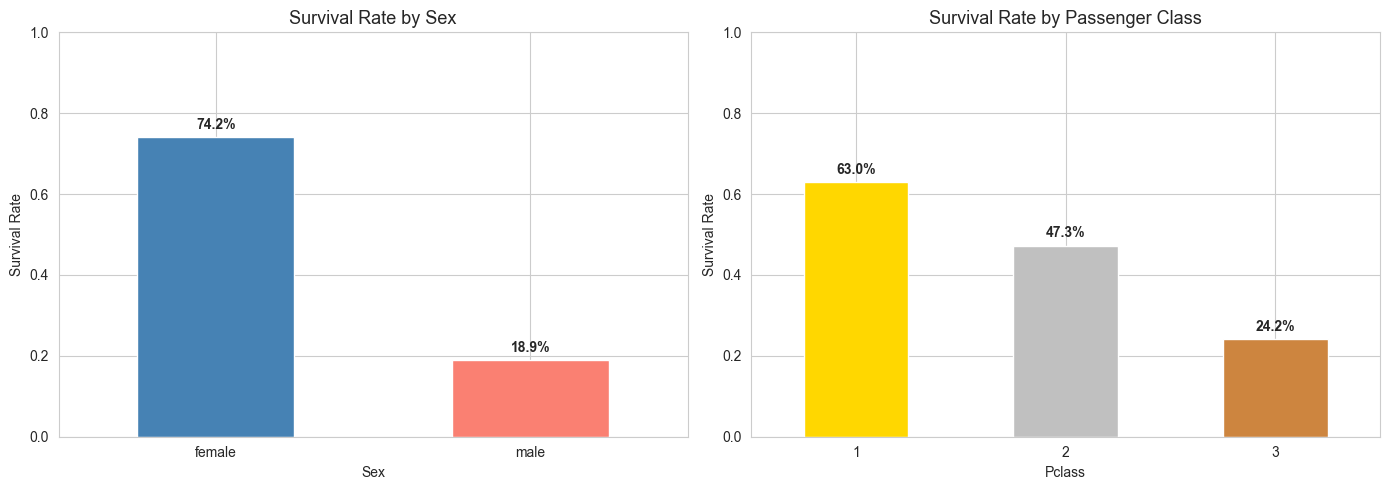

CONFIRMED: Female survival 74% vs male 19%. 1st class 63% vs 3rd class 24%.


In [54]:
# HYPOTHESIS 1: Women and children survived more (historical 'women and children first' protocol)
# HYPOTHESIS 2: 1st class passengers had better access to lifeboats
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sex_surv = train_df.groupby('Sex')['Survived'].mean()
sex_surv.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], rot=0)
axes[0].set_title('Survival Rate by Sex', fontsize=13)
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)
for i, v in enumerate(sex_surv):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

pclass_surv = train_df.groupby('Pclass')['Survived'].mean()
pclass_surv.plot(kind='bar', ax=axes[1], color=['gold', 'silver', 'peru'], rot=0)
axes[1].set_title('Survival Rate by Passenger Class', fontsize=13)
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)
for i, v in enumerate(pclass_surv):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print('CONFIRMED: Female survival 74% vs male 19%. 1st class 63% vs 3rd class 24%.')

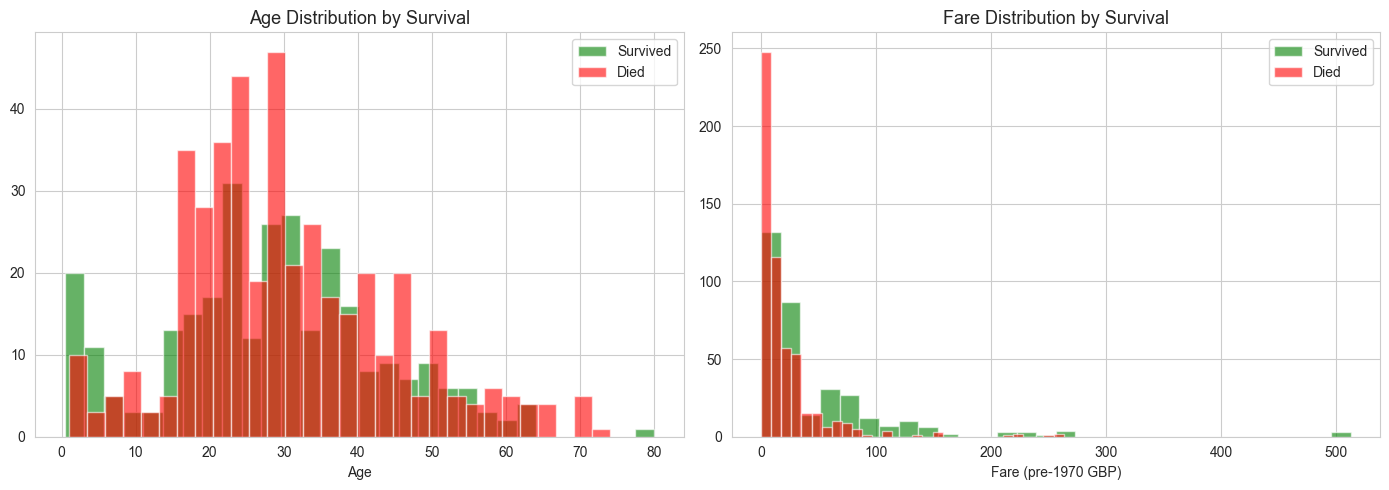

Age: 177 missing values — will impute using Title groups.
Fare: higher fare = higher class = higher survival. Will bin into categories.


In [55]:
# Age and Fare distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [(1, 'green'), (0, 'red')]:
    train_df[train_df['Survived']==label]['Age'].dropna().hist(
        ax=axes[0], bins=30, alpha=0.6, color=color, label='Survived' if label else 'Died')
    train_df[train_df['Survived']==label]['Fare'].hist(
        ax=axes[1], bins=30, alpha=0.6, color=color, label='Survived' if label else 'Died')

axes[0].set_title('Age Distribution by Survival', fontsize=13)
axes[0].set_xlabel('Age')
axes[0].legend()
axes[1].set_title('Fare Distribution by Survival', fontsize=13)
axes[1].set_xlabel('Fare (pre-1970 GBP)')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Age: {train_df["Age"].isnull().sum()} missing values — will impute using Title groups.')
print('Fare: higher fare = higher class = higher survival. Will bin into categories.')

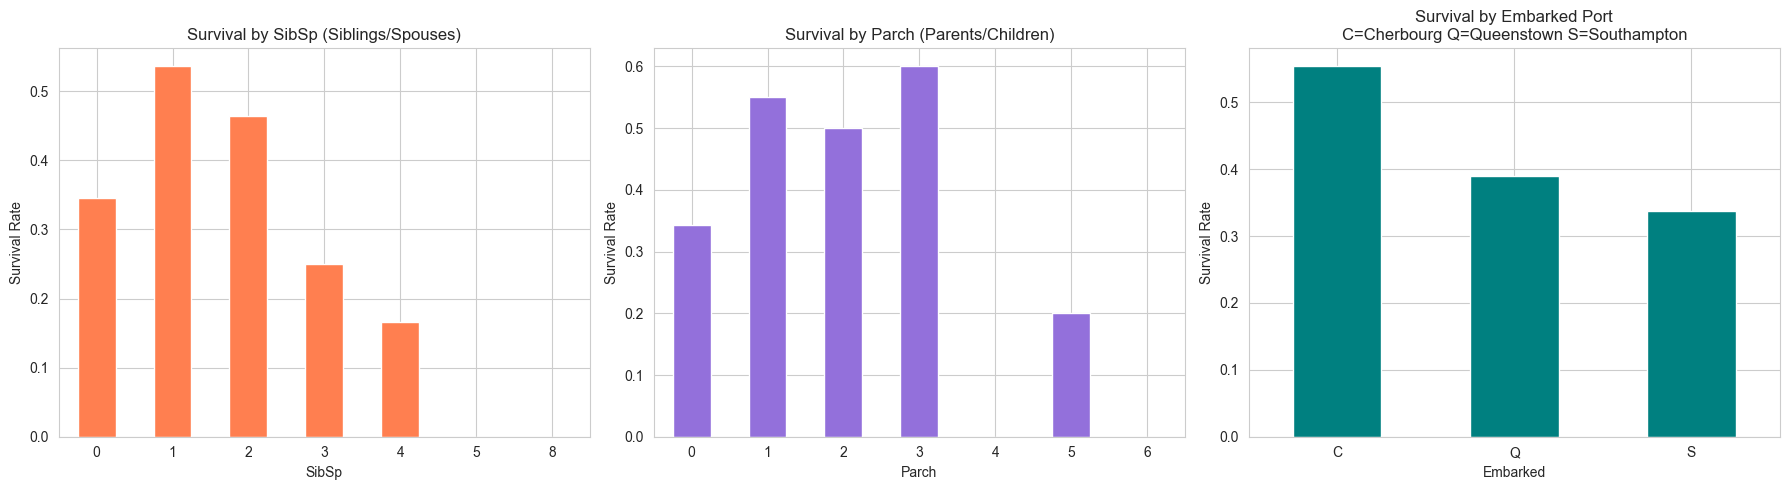

Small families (1-3) survived better than solo travelers and large families.
Embarked shows some signal — Cherbourg passengers survived most (higher class mix).
ACTION: Keep Embarked, one-hot encode it. Combine SibSp+Parch into Family_Size.


In [56]:
# Family features and Embarked
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

train_df.groupby('SibSp')['Survived'].mean().plot(kind='bar', ax=axes[0], rot=0, color='coral')
axes[0].set_title('Survival by SibSp (Siblings/Spouses)', fontsize=12)
axes[0].set_ylabel('Survival Rate')

train_df.groupby('Parch')['Survived'].mean().plot(kind='bar', ax=axes[1], rot=0, color='mediumpurple')
axes[1].set_title('Survival by Parch (Parents/Children)', fontsize=12)
axes[1].set_ylabel('Survival Rate')

train_df.groupby('Embarked')['Survived'].mean().plot(kind='bar', ax=axes[2], rot=0, color='teal')
axes[2].set_title('Survival by Embarked Port\nC=Cherbourg Q=Queenstown S=Southampton', fontsize=12)
axes[2].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()
print('Small families (1-3) survived better than solo travelers and large families.')
print('Embarked shows some signal — Cherbourg passengers survived most (higher class mix).')
print('ACTION: Keep Embarked, one-hot encode it. Combine SibSp+Parch into Family_Size.')

---
## 4. Feature Engineering

**What is Feature Engineering?** Creating new, more informative features from raw data using domain knowledge.

**Critical lesson from iteration 1:**  
Our first attempt used *label encoding* for Title (Mr=1, Miss=2, Mrs=3…). This tells the model these categories are *ordered* — that Mrs is "greater than" Miss. That is wrong. **One-hot encoding** treats each category as independent, which is correct for nominal categories like Title and Embarked.

We use `scripts/preprocessing.py` for the two most complex functions (`extract_group_survival`, `clean_data`) so the same logic can be reused in `train.py` and `predict.py` without copy-pasting.

In [57]:
full_df = pd.concat([train_df, test_df], sort=False).reset_index(drop=True)
print(f'Combined shape: {full_df.shape}')

Combined shape: (1309, 12)


### 4.1 Family & Group Survival Rate

**Why this is the most impactful single feature:**  
Passengers travelling with family or companions had correlated fates — they helped each other reach lifeboats. Knowing that a family member survived is extremely predictive.

This is computed in `preprocessing.extract_group_survival()`. Two passes:
1. Group by **last name + fare** (same family = same surname + paid together)
2. Refine by **ticket number** (travel companions who share a ticket but different surnames)

In [58]:
full_df = extract_group_survival(full_df)
full_df = clean_data(full_df)  # adds Family_Size
print('\nGroup survival and family size computed.')

  [extract_group_survival] Passengers with family/group info: 546 / 1309
  [clean_data] Family_Size created. Range: 1–11

Group survival and family size computed.


### 4.2 Title — Name Encodes Social Status, Gender, and Age Group

**Why extract Title from Name?**  
The Name column contains titles like `Mr`, `Mrs`, `Miss`, `Master`, `Dr` etc. These encode:
- Gender (Mr = male, Mrs/Miss = female)
- Age group (Master = boy under ~15, meaning higher survival)
- Social status (Sir, Lady, Countess = elite class)

**Why one-hot encode instead of label encode?**  
Label encoding (`Mr=1, Miss=2, Mrs=3`) implies ordering — that Mrs is mathematically greater than Mr. There is no such ordering. One-hot encoding creates separate binary columns (`Title_Mr`, `Title_Miss`, etc.) treating each as independent.

In [59]:
# Extract title from Name using regex
full_df['Title'] = full_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Consolidate rare/foreign titles
mapping = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Major': 'Mr',  'Col': 'Mr',  'Dr': 'Mr',
    'Rev': 'Mr',    'Capt': 'Mr', 'Jonkheer': 'Mr',
    'Sir': 'Mr',    'Don': 'Mr',
    'Lady': 'Mrs',  'Countess': 'Mrs', 'Dona': 'Mrs'
}
full_df.replace({'Title': mapping}, inplace=True)

# Impute missing Age using median of each Title group
# Why title-based median? A Master is ~5 years old, an Mr is ~30.
# Using the overall median for both would introduce noise.
full_df['Age'] = full_df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

print('Unique titles after mapping:', full_df['Title'].unique())
print(f'Missing Age after imputation: {full_df["Age"].isnull().sum()}')

Unique titles after mapping: <StringArray>
['Mr', 'Mrs', 'Miss', 'Master']
Length: 4, dtype: str
Missing Age after imputation: 0


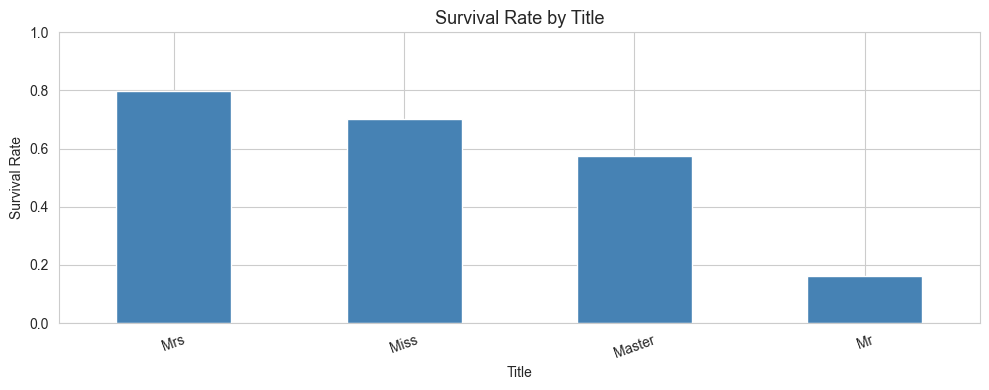

Mrs/Miss/Master survive at high rates. Mr at ~16%. Title is highly predictive.


In [60]:
# Visualize: survival rate per title (train only)
train_view = full_df[:len(train_df)].copy()
title_surv  = train_view.groupby('Title')['Survived'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
title_surv.plot(kind='bar', color='steelblue', rot=20)
plt.title('Survival Rate by Title', fontsize=13)
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
print('Mrs/Miss/Master survive at high rates. Mr at ~16%. Title is highly predictive.')

### 4.3 Fill Remaining Missing Values

In [61]:
full_df['Fare']     = full_df['Fare'].fillna(full_df['Fare'].median())
full_df['Embarked'] = full_df['Embarked'].fillna(full_df['Embarked'].mode()[0])

print('Missing values after filling:')
print(full_df.isnull().sum()[full_df.isnull().sum() > 0])
print('(Survived NaN is expected — that is the test set target we need to predict)')

Missing values after filling:
Survived     418
Cabin       1014
dtype: int64
(Survived NaN is expected — that is the test set target we need to predict)


### 4.4 Encode Categorical Variables

**Sex:** binary map (male=0, female=1)  
**Embarked:** one-hot → `Emb_C`, `Emb_Q`, `Emb_S`  
**Title:** one-hot → `Title_Master`, `Title_Miss`, `Title_Mr`, `Title_Mrs`

**Why one-hot for Embarked too?**  
Ports have no meaningful order. C > Q > S has no interpretation. One-hot lets the model learn each port's effect independently.

In [62]:
full_df['Sex'] = full_df['Sex'].map({'male': 0, 'female': 1})
full_df = pd.get_dummies(full_df, columns=['Embarked', 'Title'], prefix=['Emb', 'Title'])

print('New columns after one-hot encoding:')
new_cols = [c for c in full_df.columns if c.startswith('Emb_') or c.startswith('Title_')]
print(new_cols)
print(f'\nFull dataset shape: {full_df.shape}')

New columns after one-hot encoding:
['Emb_C', 'Emb_Q', 'Emb_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs']

Full dataset shape: (1309, 21)


### 4.5 Visualize Engineered Features vs Survival

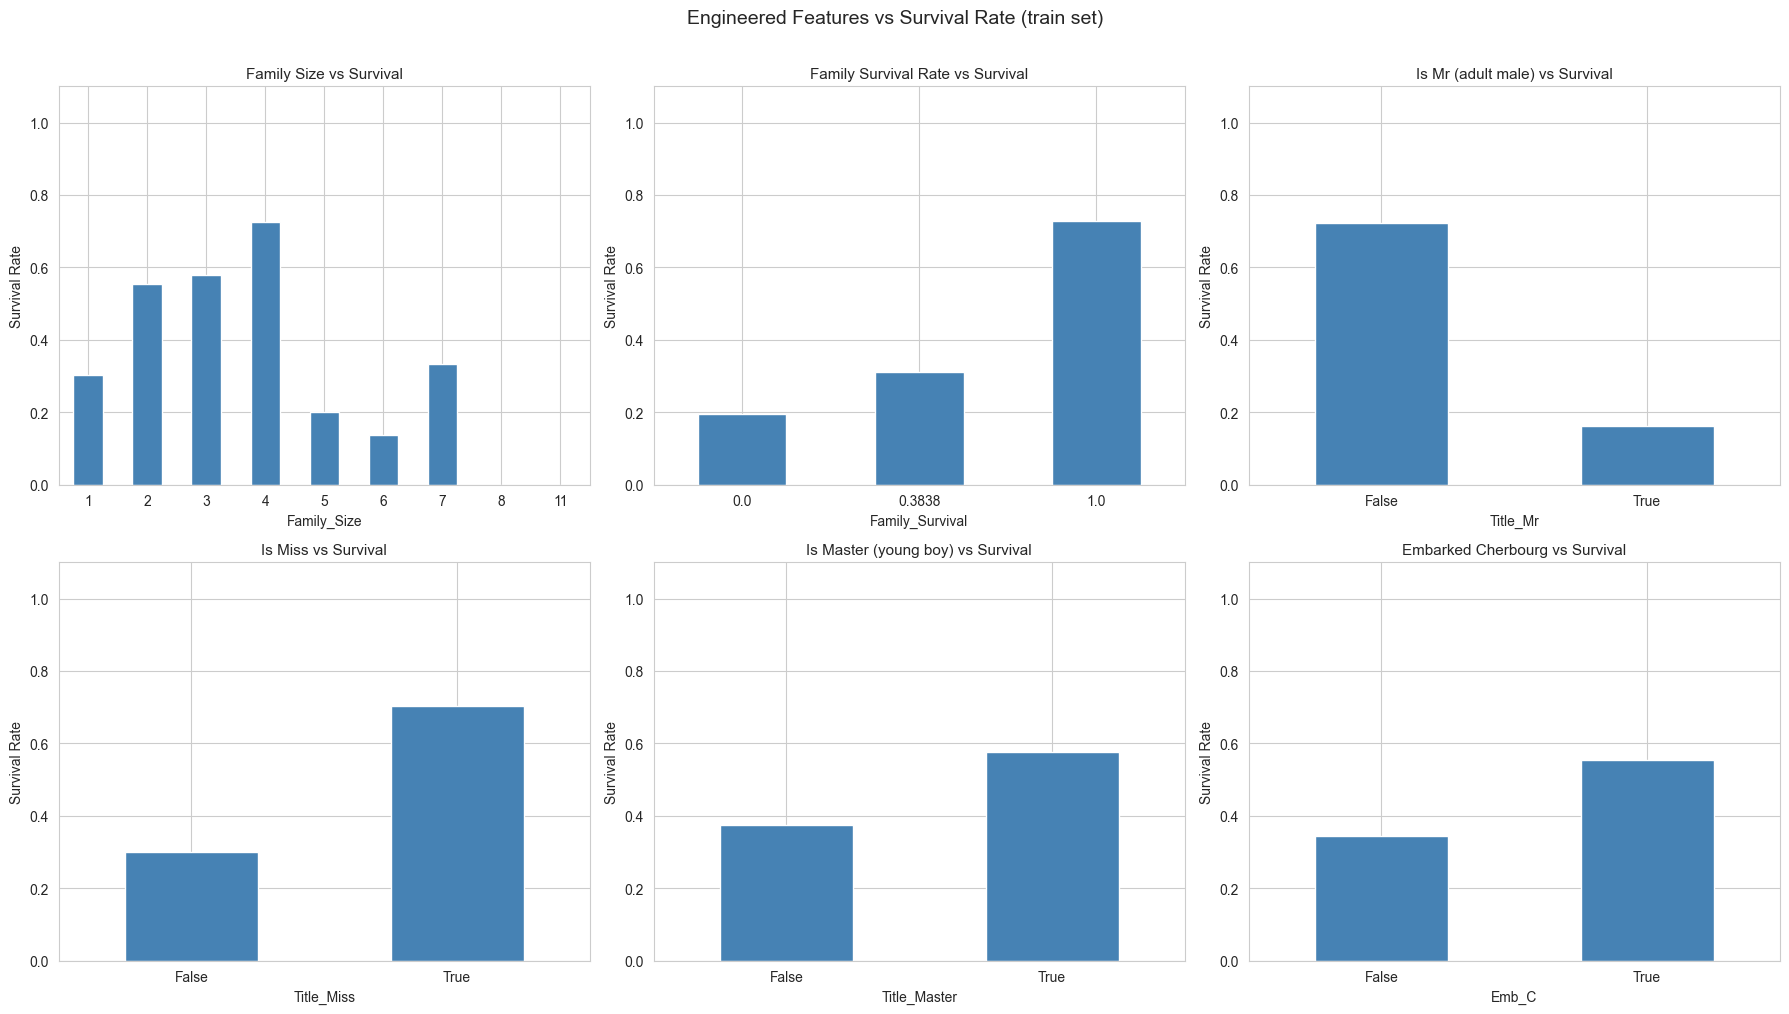

In [63]:
train_fe = full_df[:len(train_df)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

features_to_plot = [
    ('Family_Size',      'Family Size'),
    ('Family_Survival',  'Family Survival Rate'),
    ('Title_Mr',         'Is Mr (adult male)'),
    ('Title_Miss',       'Is Miss'),
    ('Title_Master',     'Is Master (young boy)'),
    ('Emb_C',            'Embarked Cherbourg'),
]

for ax, (col, title) in zip(axes, features_to_plot):
    train_fe.groupby(col)['Survived'].mean().plot(kind='bar', ax=ax, rot=0, color='steelblue')
    ax.set_title(f'{title} vs Survival', fontsize=11)
    ax.set_ylabel('Survival Rate')
    ax.set_ylim(0, 1.1)

plt.suptitle('Engineered Features vs Survival Rate (train set)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Prepare Final Feature Set

In [64]:
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Last_Name', 'Survived']

X_full  = full_df.drop(columns=drop_cols)
y_full  = full_df['Survived']

X_train = X_full[:len(train_df)]
y_train = y_full[:len(train_df)].astype(int)
X_test  = X_full[len(train_df):]

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Missing values in X_train: {X_train.isna().sum().sum()}')
print(f'Features: {X_train.columns.tolist()}')

X_train: (891, 15) | X_test: (418, 15)
Missing values in X_train: 0
Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Family_Survival', 'Family_Size', 'Emb_C', 'Emb_Q', 'Emb_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs']


---
## 6. Feature Scaling

**Why scale?** KNN uses distance — `Name_Length` (10–40) would dominate `Pclass` (1–3) without scaling. `StandardScaler` normalises each feature to mean=0, std=1.

**Rule:** fit on train only, then transform both. Fitting on test leaks information.

In [65]:
scaler        = StandardScaler()
X_train_sc    = scaler.fit_transform(X_train)
X_test_sc     = scaler.transform(X_test)
print('Scaling complete.')

Scaling complete.


---
## 7. Model Comparison — 10-Fold Cross-Validation

**What is overfitting?** A model that memorises training data does well on train but poorly on unseen data. CV simulates unseen data by rotating which fold is used for validation.

**StratifiedKFold** preserves the class ratio (survived/died) in each fold — important because only 38% survived.

| Model | Strength | Weakness |
|---|---|---|
| Logistic Regression | Simple, interpretable, fast | Only linear boundaries |
| Decision Tree | Non-linear, easy to visualise | Overfits easily |
| Random Forest | Ensemble — reduces overfitting | Less interpretable |
| Gradient Boosting | Often highest accuracy | Slow, many hyperparams |
| KNN | No assumptions about data shape | Sensitive to feature scaling |

In [66]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=10),
}

kfold   = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = {}

print('10-Fold Stratified Cross-Validation:')
print(f'{"Model":<25} {"Mean CV":>10} {"Std":>8}')
print('-' * 46)

for name, model in models.items():
    scores        = cross_val_score(model, X_train_sc, y_train, cv=kfold, scoring='accuracy')
    results[name] = scores
    print(f'{name:<25} {scores.mean():>10.4f} {scores.std():>8.4f}')

10-Fold Stratified Cross-Validation:
Model                        Mean CV      Std
----------------------------------------------
Logistic Regression           0.8428   0.0299
Decision Tree                 0.8540   0.0258
Random Forest                 0.8496   0.0233
Gradient Boosting             0.8485   0.0259
KNN                           0.8417   0.0224


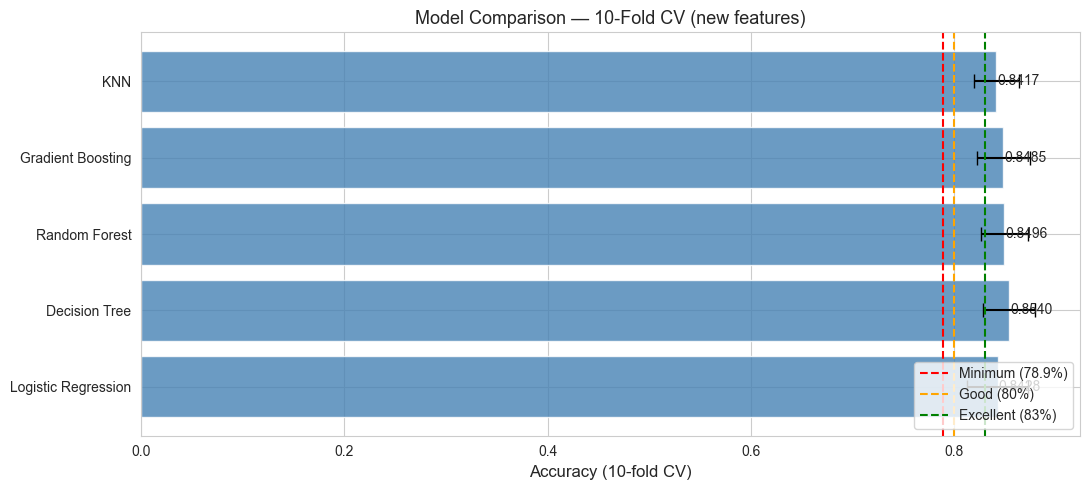

In [67]:
means = [results[m].mean() for m in models]
stds  = [results[m].std()  for m in models]
names = list(models.keys())

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(names, means, xerr=stds, color='steelblue', alpha=0.8, capsize=5)
ax.axvline(x=0.789, color='red',    linestyle='--', label='Minimum (78.9%)')
ax.axvline(x=0.80,  color='orange', linestyle='--', label='Good (80%)')
ax.axvline(x=0.83,  color='green',  linestyle='--', label='Excellent (83%)')
for bar, mean in zip(bars, means):
    ax.text(mean + 0.001, bar.get_y() + bar.get_height()/2, f'{mean:.4f}', va='center', fontsize=10)
ax.set_xlabel('Accuracy (10-fold CV)', fontsize=12)
ax.set_title('Model Comparison — 10-Fold CV (new features)', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 8. Hyperparameter Tuning — GridSearchCV

**What is GridSearchCV?** Tests every combination of hyperparameters using cross-validation and returns the best set. Removes guesswork and prevents manually overfitting to one split.

All 5 models are tuned separately so each submission file is the best possible version of that model.

In [68]:
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=500, random_state=42),
    {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']},
    cv=kfold, scoring='accuracy', n_jobs=-1
)
lr_grid.fit(X_train_sc, y_train)
print(f'LR  best: {lr_grid.best_params_}  CV: {lr_grid.best_score_:.4f}')

LR  best: {'C': 0.1, 'solver': 'lbfgs'}  CV: 0.8462


In [69]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {'max_depth': [3, 4, 5, 6, 7], 'min_samples_split': [2, 5, 10]},
    cv=kfold, scoring='accuracy', n_jobs=-1
)
dt_grid.fit(X_train_sc, y_train)
print(f'DT  best: {dt_grid.best_params_}  CV: {dt_grid.best_score_:.4f}')

DT  best: {'max_depth': 3, 'min_samples_split': 2}  CV: 0.8552


In [70]:
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {'n_estimators': [100, 200], 'max_depth': [3, 4, 5], 'learning_rate': [0.05, 0.1]},
    cv=kfold, scoring='accuracy', n_jobs=-1
)
gb_grid.fit(X_train_sc, y_train)
print(f'GB  best: {gb_grid.best_params_}  CV: {gb_grid.best_score_:.4f}')

GB  best: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}  CV: 0.8485


In [71]:
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [6, 8, 10, 12, 14, 16, 18, 20], 'weights': ['uniform', 'distance'], 'leaf_size': list(range(1, 30, 5))},
    cv=kfold, scoring='accuracy', n_jobs=-1
)
knn_grid.fit(X_train_sc, y_train)
print(f'KNN best: {knn_grid.best_params_}  CV: {knn_grid.best_score_:.4f}')

KNN best: {'leaf_size': 1, 'n_neighbors': 10, 'weights': 'uniform'}  CV: 0.8428


In [72]:
# Tuned CV summary
tuned = {
    'Logistic Regression': lr_grid.best_score_,
    'Decision Tree':       dt_grid.best_score_,
    'Random Forest':       rf_grid.best_score_,
    'Gradient Boosting':   gb_grid.best_score_,
    'KNN':                 knn_grid.best_score_,
}
print('\nTuned CV Scores:')
print(f'{"Model":<25} {"CV Score":>10}')
print('-' * 37)
for name, score in sorted(tuned.items(), key=lambda x: -x[1]):
    print(f'{name:<25} {score:>10.4f}')


Tuned CV Scores:
Model                       CV Score
-------------------------------------
Random Forest                 0.8563
Decision Tree                 0.8552
Gradient Boosting             0.8485
Logistic Regression           0.8462
KNN                           0.8428


---
## 9. Generate One Submission Per Model

**Why submit each model?**  
CV score (on training folds) ≠ Kaggle score (truly unseen test data). The model with the best CV is not always the best on Kaggle. Submitting all 5 lets us measure which one actually generalises best.

Each file is saved as `data/submission_<model>.csv`.

In [73]:
best_models = {
    'logistic_regression': lr_grid.best_estimator_,
    'decision_tree':       dt_grid.best_estimator_,
    'random_forest':       rf_grid.best_estimator_,
    'gradient_boosting':   gb_grid.best_estimator_,
    'knn':                 knn_grid.best_estimator_,
}

for model_name, model in best_models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    sub = pd.DataFrame({
        'PassengerId': test_df['PassengerId'],
        'Survived':    preds.astype(int)
    })
    path = f'../data/submission_{model_name}.csv'
    sub.to_csv(path, index=False)
    print(f'{model_name:<25} → saved  (survivors: {preds.sum()}/{len(preds)})')

print('\nAll 5 submissions saved. Upload each to Kaggle and record scores in section 10.')

logistic_regression       → saved  (survivors: 159/418)
decision_tree             → saved  (survivors: 148/418)
random_forest             → saved  (survivors: 152/418)
gradient_boosting         → saved  (survivors: 152/418)
knn                       → saved  (survivors: 144/418)

All 5 submissions saved. Upload each to Kaggle and record scores in section 10.


---
## 10. Kaggle Results


| Model | CV Score (local) | Kaggle Score | Gap |
|---|---|---|---|
| Logistic Regression | 0.8462 | 0.77751 | 0.06869 |
| Decision Tree | 0.8552 | 0.80382 | 0.05138 |
| Random Forest | 0.8563 | 0.79425 | 0.06205 |
| Gradient Boosting | 0.8485 | 0.78947 | 0.05903 |
| KNN | 0.8428 | 0.78468 | 0.05812 |

**Previous attempt scores (old features, label encoding):**

| Model | Kaggle Score |
|---|---|
| Logistic Regression | 0.77751 |
| Decision Tree | 0.79904 |
| Random Forest | 0.78947 |
| Gradient Boosting | 0.78468 |
| KNN | 0.79904 |

---
## 11. Evaluation Metrics — Best Model Deep Dive

**Why not just accuracy?**  
If 62% of passengers died, a model predicting everyone dies scores 62% — but is useless.
- **Precision** = of all predicted survivors, how many actually survived?
- **Recall** = of all actual survivors, how many did we correctly find?
- **F1** = harmonic mean of precision and recall

In [74]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train_sc, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(f'{"Model":<25} {"Accuracy":>10} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-' * 65)

for model_name, model in best_models.items():
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    print(f'{model_name:<25} {accuracy_score(y_val,y_pred):>10.4f} '
          f'{precision_score(y_val,y_pred):>10.4f} '
          f'{recall_score(y_val,y_pred):>8.4f} '
          f'{f1_score(y_val,y_pred):>8.4f}')

Model                       Accuracy  Precision   Recall       F1
-----------------------------------------------------------------
logistic_regression           0.8156     0.7812   0.7246   0.7519
decision_tree                 0.8268     0.8393   0.6812   0.7520
random_forest                 0.8156     0.8103   0.6812   0.7402
gradient_boosting             0.8101     0.7692   0.7246   0.7463
knn                           0.8380     0.8571   0.6957   0.7680


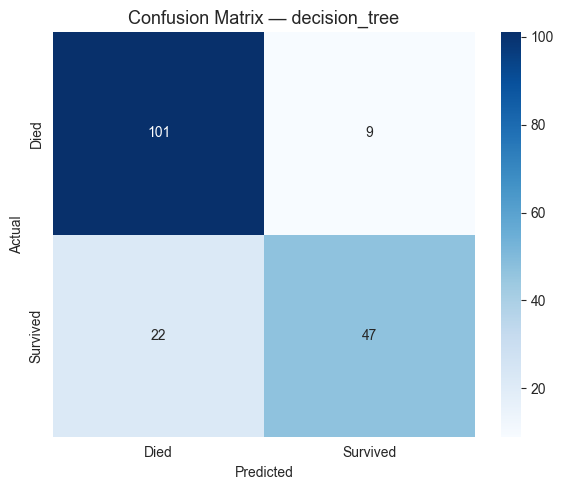

In [77]:
# Confusion matrix
best_kaggle_name  = 'decision_tree'
best_kaggle_model = best_models[best_kaggle_name]
best_kaggle_model.fit(X_tr, y_tr)
y_pred = best_kaggle_model.predict(X_val)

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died','Survived'], yticklabels=['Died','Survived'])
plt.title(f'Confusion Matrix — {best_kaggle_name}', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## 12. Summary — What Was Learned

| Concept | Applied here |
|---|---|
| **Feature engineering** | Title (one-hot), Family_Size, Family_Survival, Embarked (one-hot) |
| **Encoding choice** | One-hot > label encoding for nominal categories — no false ordering |
| **Modular code** | `preprocessing.py` keeps complex logic reusable across notebook and scripts |
| **EDA** | Survival rate plots to confirm hypotheses before modeling |
| **Missing data** | Age by title-group median; Fare/Embarked by median/mode |
| **Cross-validation** | 10-fold StratifiedKFold — reliable accuracy without overfitting |
| **GridSearchCV** | All 5 models tuned independently |
| **Submission strategy** | One file per model → compare Kaggle scores → pick winner |
| **CV vs Kaggle gap** | A smaller gap = better generalisation = more trustworthy model |

**Key lesson from iteration 1 → 2:**  
Label encoding Title introduced a false numerical ordering the model treated as signal. Switching to one-hot encoding removed that noise. The feature set that gives the best *Kaggle* score — not just the best CV score — is the right one.